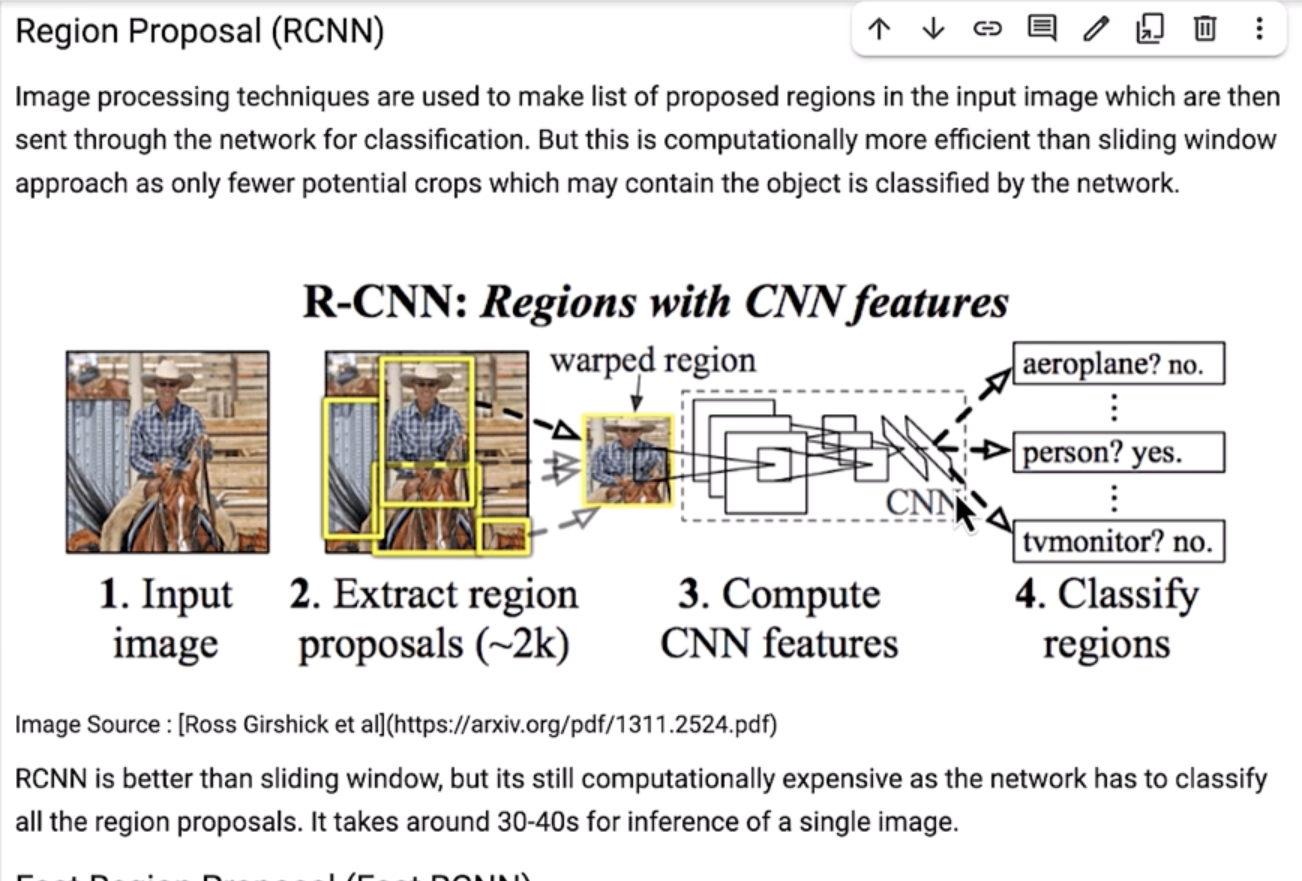

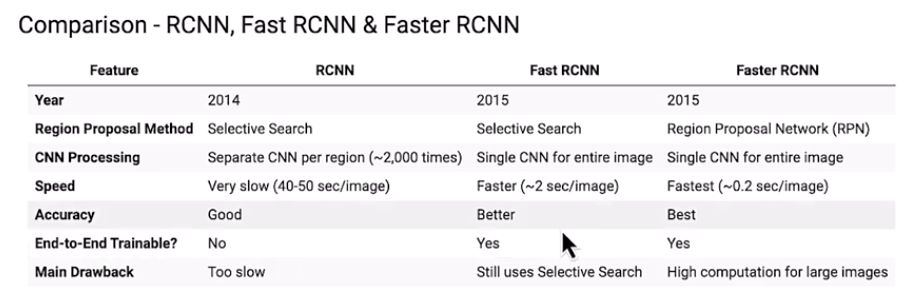

In [39]:
from IPython.display import Image, display

display(Image(filename='data/notebook-imgs/rcnn.png', width=400, height=200))
display(Image(filename='data/notebook-imgs/rcnn-evolution.png', width=400, height=200))

In [4]:
from PIL import Image
from torchvision import models

import os
import torch
import time
import requests
import subprocess
import numpy as np
import torchvision
import matplotlib.pyplot as plt

plt.style.use('ggplot')

np.random.seed(20)

In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
model.eval() # if dont put eval, the model will do alot of additional computation used for training

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/I748920/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:03<00:00, 55.6MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

COCO --> Common Objects in Context

In [9]:
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
categories = weights.meta["categories"]
type(categories), categories[:10]

(list,
 ['__background__',
  'person',
  'bicycle',
  'car',
  'motorcycle',
  'airplane',
  'bus',
  'train',
  'truck',
  'boat'])

In [12]:
# Create a colors mapping for each predicted class
COLORS = np.random.uniform(0,255, size=(len(categories), 3))
COLORS.shape

(91, 3)

In [13]:
# test a forward pass

In [14]:
path = "data/cat-and-dog1.jpeg"
image = Image.open(path)

In [16]:
import torchvision.transforms as T

def transforms(image):
    t = T.Compose([
        T.ToTensor()
    ])
    return t(image)

In [17]:
t_image = transforms(image)

In [19]:
t_image.shape

torch.Size([3, 1200, 1200])

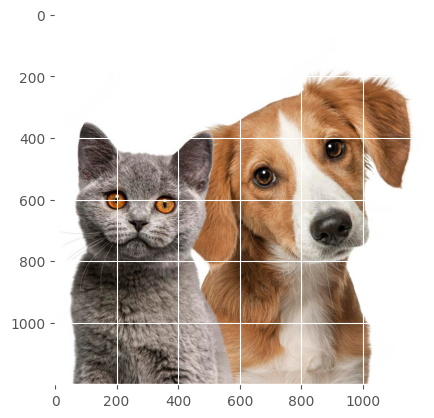

In [ ]:
# plt.imshow(t_image.permute(1,2,0))

In [ ]:
out = model(t_image.unsqueeze(0)) # this model will resize the input image automatically

In [28]:
out

[{'boxes': tensor([[ 299.4839,  164.7880, 1155.7720, 1189.6006],
          [  49.4014,  349.8540,  567.0830, 1193.1323],
          [ 256.7930,  212.3140, 1095.3735, 1182.1826],
          [  23.4137,  255.7612, 1175.9299, 1155.9714],
          [   0.0000,  248.8466, 1185.0037, 1136.8462],
          [  30.4471,  330.3851,  620.8275, 1191.4106]],
         grad_fn=<StackBackward0>),
  'labels': tensor([18, 17, 17, 63, 15, 18]),
  'scores': tensor([0.9932, 0.9899, 0.1980, 0.0817, 0.0618, 0.0592],
         grad_fn=<IndexBackward0>)}]

In [45]:
import torch
from PIL import Image
from torchvision import transforms

# Load COCO label map
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
CATEGORIES = FasterRCNN_ResNet50_FPN_Weights.DEFAULT.meta["categories"]

def run_detection(model, image_path, score_thresh=0.5):
    """
    Loads an image, runs FasterRCNN forward pass, and returns boxes + classes.

    Args:
        model: FasterRCNN model in eval mode.
        image_path (str): Path to image.
        score_thresh (float): Minimum confidence score to keep detections.

    Returns:
        pred_boxes (Tensor): (N, 4) bounding boxes.
        pred_classes (List[str]): Class names for each detection.
    """

    # Load + preprocess
    img = Image.open(image_path).convert("RGB")
    transform = transforms.ToTensor()
    img_tensor = transform(img)

    # Forward pass
    with torch.no_grad(): # with this line, you dont need to do .detach().cpu().numpy()
        outputs = model([img_tensor])

    # Extract predictions
    pred_boxes = outputs[0]["boxes"].cpu()
    pred_labels = outputs[0]["labels"].cpu()
    pred_scores = outputs[0]["scores"].cpu()


    # Filter by score
    keep = pred_scores > score_thresh
    pred_boxes = pred_boxes[keep]
    pred_labels = pred_labels[keep]

    pred_classes = [CATEGORIES[i] for i in pred_labels.tolist()]

    return img, pred_boxes, pred_classes


In [30]:
out = run_detection(model=model, image_path='data/cat-and-dog1.jpeg', score_thresh=0.6)

In [31]:
out[1], out[2]

(tensor([[ 299.4839,  164.7880, 1155.7720, 1189.6006],
         [  49.4014,  349.8540,  567.0830, 1193.1323]]),
 ['dog', 'cat'])

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_detections(img, boxes, classes, figsize=(10, 7)):
    """
    Draws bounding boxes + labels on an image.

    Args:
        img (PIL.Image): Original image.
        boxes (Tensor): Bounding boxes.
        classes (List[str]): Class names for each box.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()

    for box, cls in zip(boxes, classes):
        x1, y1, x2, y2 = box.tolist()

        # Draw bounding box
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

        # Draw label background
        ax.text(
            x1, y1 - 3,
            cls,
            fontsize=10,
            color='white',
            bbox=dict(facecolor='red', alpha=0.7, pad=2)
        )

    plt.axis("off")
    plt.show()


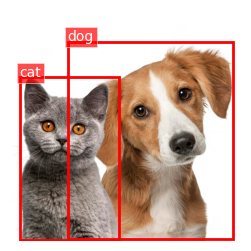

In [35]:
out = run_detection(model=model, image_path='data/cat-and-dog1.jpeg', score_thresh=0.6)
draw_detections(out[0], out[1], out[2], figsize=(5,3))

In [1]:
out

NameError: name 'out' is not defined

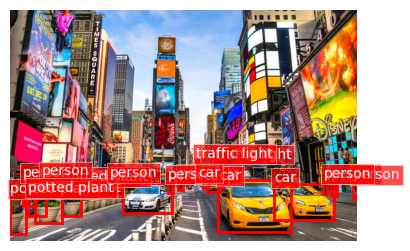

In [ ]:
out = run_detection(model=model, image_path='data/busy-street.jpg', score_thresh=0.6)
draw_detections(out[0], out[1], out[2], figsize=(5,3))

| Aspect                                   | **Object Detection** (e.g., Faster R-CNN)                                                                                                      | **Semantic Segmentation** (e.g., FCN, DeepLab)                                    |
| ---------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| **What the model predicts**              | Bounding boxes + class label per object                                                                                                        | Class label **per pixel**                                                         |
| **Training labels**                      | • Bounding box coordinates (x1,y1,x2,y2)<br>• Class label for each box                                                                         | • Pixel-wise mask (H×W) where each pixel has a class ID                           |
| **Supervision format**                   | Sparse – only a few boxes per image                                                                                                            | Dense – every pixel is labeled                                                    |
| **Loss functions**                       | 1. **Classification loss** (cross-entropy)<br>2. **Bounding box regression loss** (Smooth L1 / GIoU / DIoU)<br>3. **RPN losses** for proposals | 1. **Pixel-wise cross entropy**<br>2. Optional **auxiliary loss** (e.g., DeepLab) |
| **Training pipeline complexity**         | High: RPN, anchor matching, positive/negative samples, IoU thresholds, NMS                                                                     | Simpler: treat as per-pixel classification (large image-level context)            |
| **How training batches work**            | For each image: generate anchors → compute IoU → assign positives/negatives                                                                    | Forward pass → compute loss per pixel → average the loss                          |
| **Model outputs before post-processing** | Hundreds/thousands of boxes + scores → need NMS                                                                                                | Raw logits mask H×W×C → softmax → per-pixel class                                 |
| **Post-processing required?**            | **Yes**: NMS to remove duplicates                                                                                                              | **No**: direct pixel classification                                               |
| **Which one is harder?**                 | Generally **detection is harder** due to localization + classification + box regression                                                        | Still heavy, but mathematically simpler (no boxes/NMS)                            |


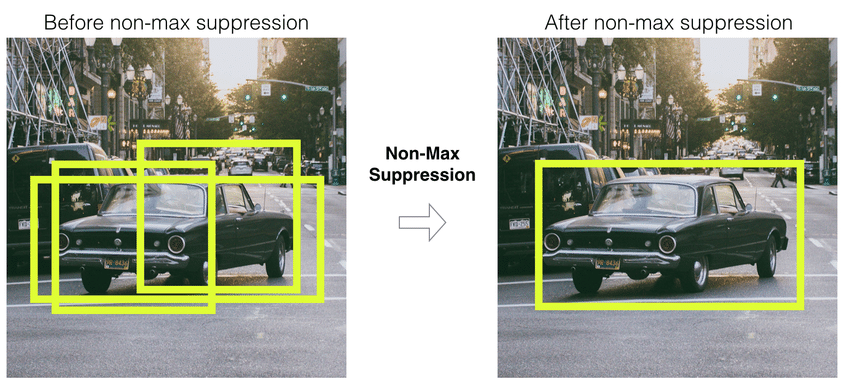

In [ ]:
display(Image(filename='data/notebook-imgs/nms.png', width=400, height=200))

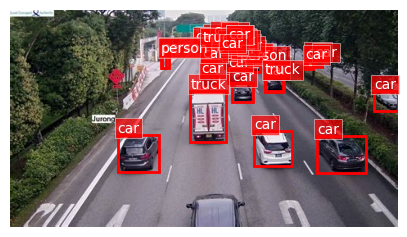

In [49]:
out = run_detection(model=model, image_path='data/aye.jpg', score_thresh=0.2)
draw_detections(out[0], out[1], out[2], figsize=(5,3))

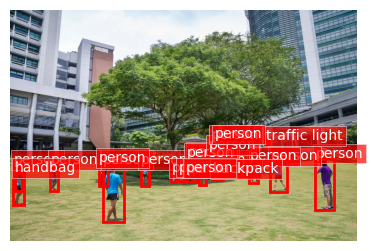

In [53]:
# out = run_detection(model=model, image_path='data/utown.png', score_thresh=0.2)
draw_detections(out[0], out[1], out[2], figsize=(5,3))

experiments show that GPU is 10x faster than CPU